# Laboratorio 2. Deep Learning — Avance LSTM

**Nina Nájera Marakovits**  
**Carné:** 231088  
**Curso:** CC3084 Data Science  
**Semestre:** II–2026

## Metodología

Se utilizaron únicamente los registros clasificados como Turista y Excursionista, igual que en el Laboratorio 1. Para reducir los cambios fuertes de escala se aplicó la transformación `log(1 + x)` y posteriormente una estandarización calculada únicamente con el conjunto de entrenamiento.

Los modelos se evaluaron mediante un esquema walk-forward de un mes adelante. Para predecir cada mes se utilizaron únicamente observaciones reales anteriores a ese mes; el valor que se estaba prediciendo nunca se incluyó dentro de su propia entrada.

Se construyeron dos arquitecturas:

- LSTM simple: una capa LSTM seguida de capas densas.
- LSTM apilada: dos capas LSTM con dropout, seguidas de capas densas.

Para el tuneo se reservaron los últimos 36 meses del conjunto de entrenamiento como validación. La mejor configuración se seleccionó con el menor RMSE de validación. Se probaron ventanas de 12 y 24 meses, diferentes cantidades de unidades ocultas y, en el modelo apilado, valores de dropout de 0.10 y 0.25. Todos los modelos se entrenaron durante 100 épocas con Adam y una tasa de aprendizaje de 0.003.

## Hiperparámetros seleccionados

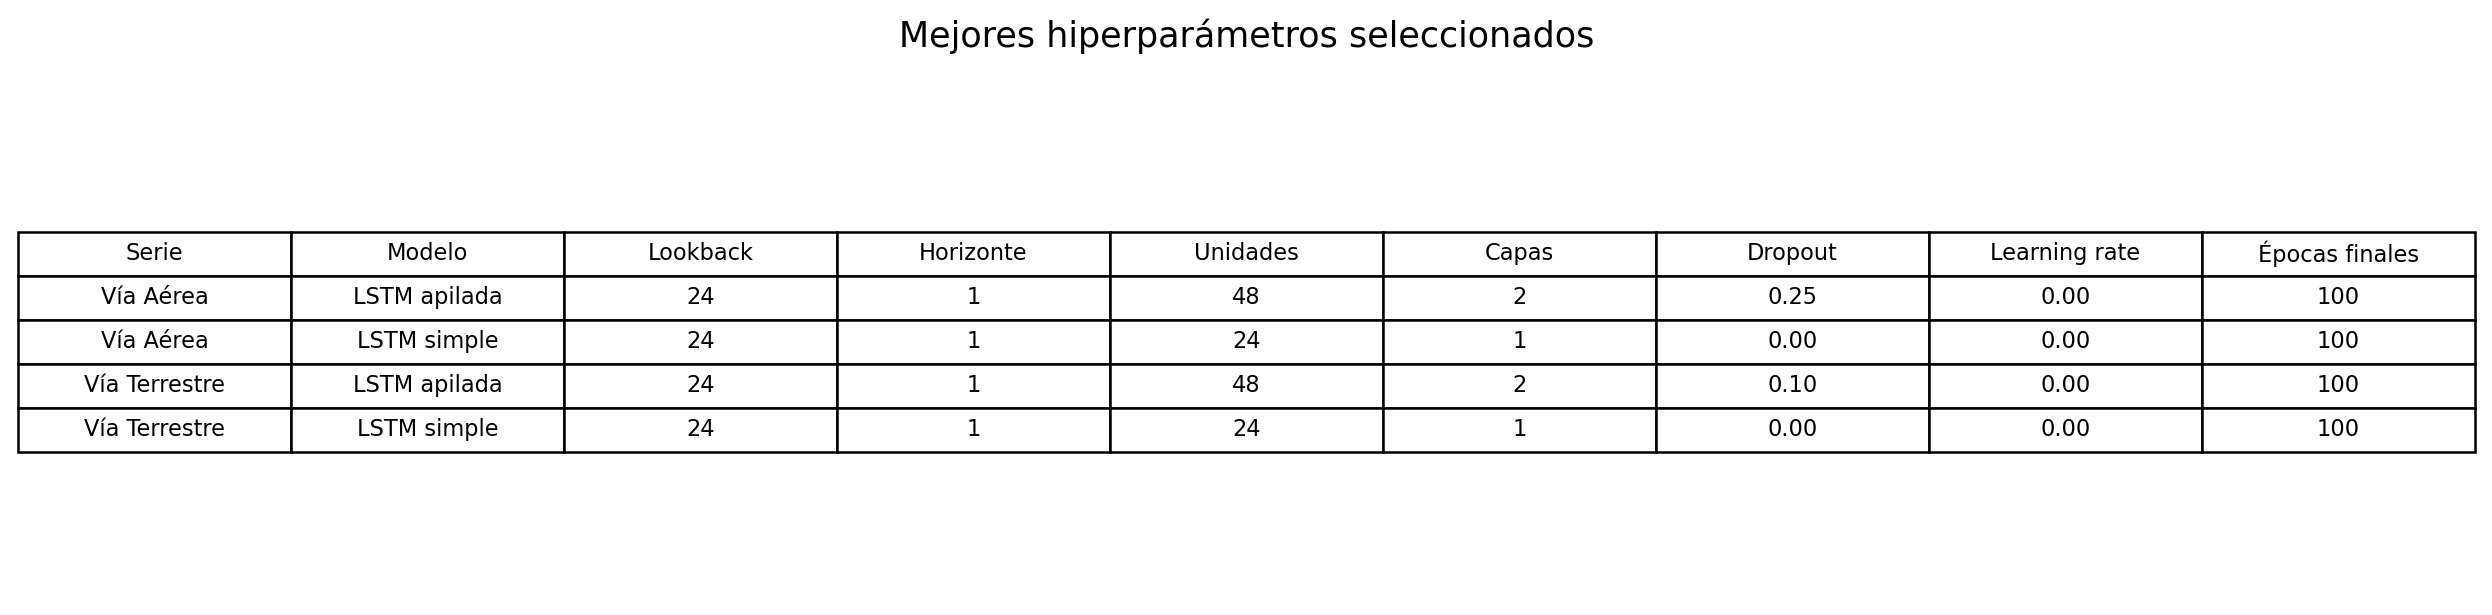

En los cuatro modelos seleccionados se eligió una ventana de 24 meses, por lo que observar dos ciclos anuales completos fue más útil que trabajar únicamente con los 12 meses anteriores. Las LSTM simples seleccionaron 24 unidades ocultas, mientras que las arquitecturas apiladas utilizaron 48 unidades y dropout.

## Resultados generales

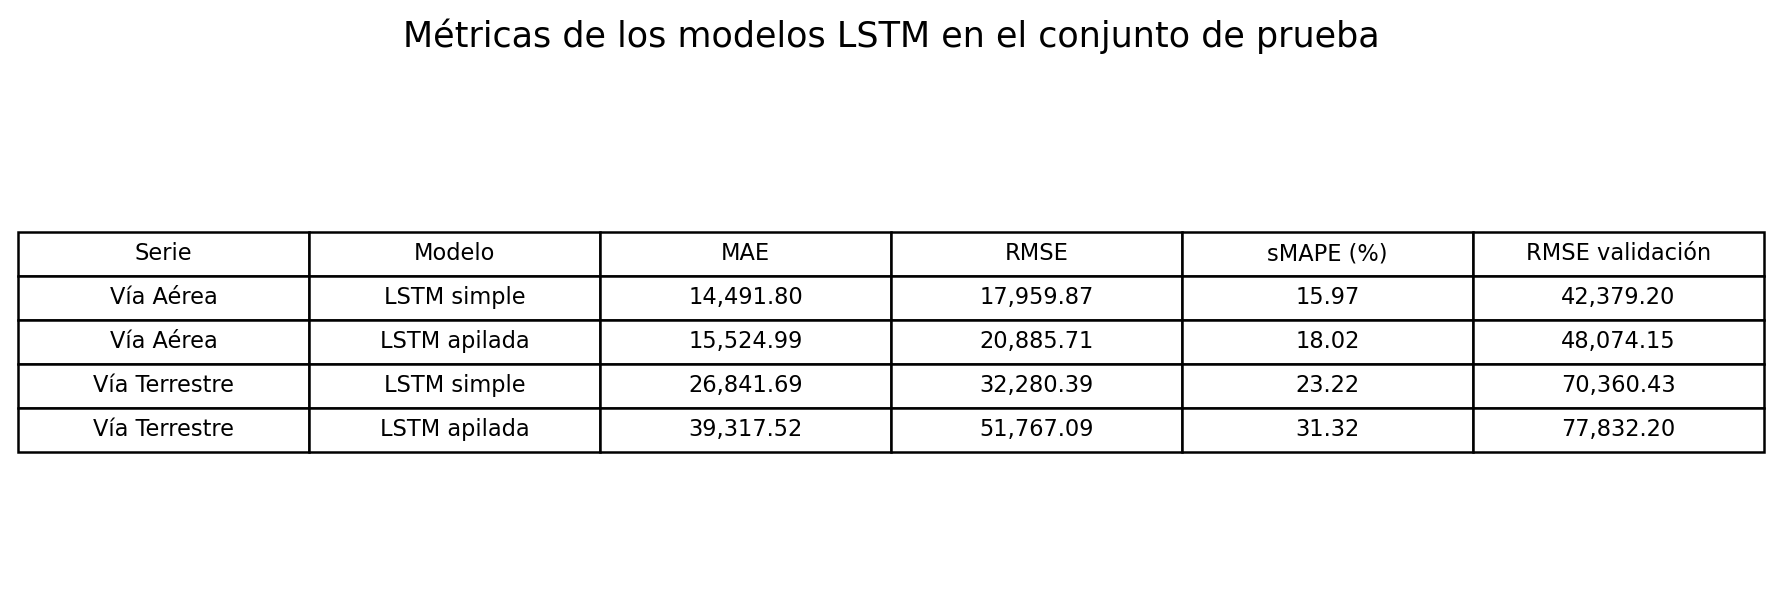

El modelo con menor error en ambas series fue la LSTM simple. La arquitectura apilada fue capaz de seguir el comportamiento general, pero presentó más errores en cambios bruscos y en algunos picos. Esto demuestra que aumentar la profundidad de la red no garantiza automáticamente una mejor predicción.

## Serie Vía Aérea — Tuneo

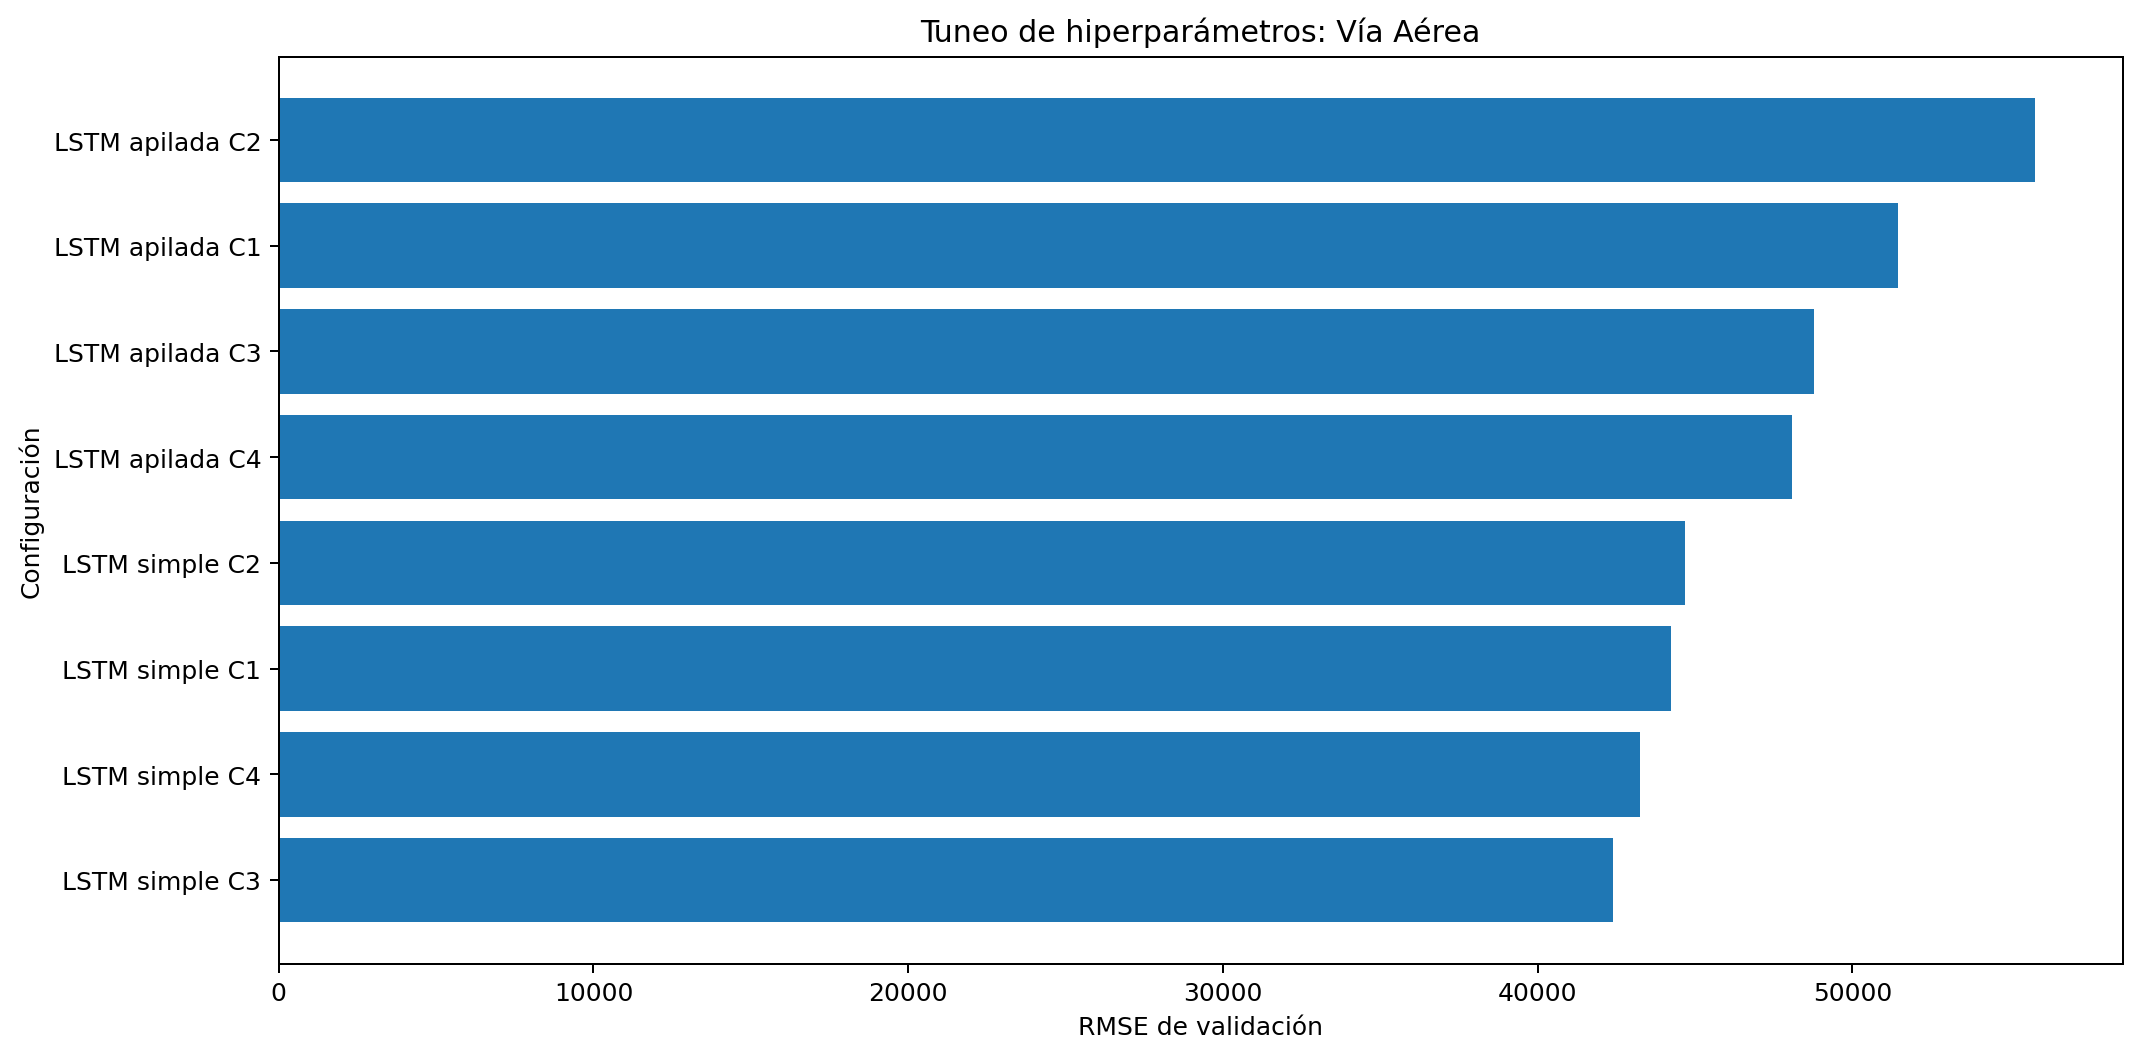

Para la serie aérea, la mejor configuración simple utilizó una ventana de 24 meses y 24 unidades ocultas. La mejor configuración apilada utilizó 24 meses, 48 unidades y dropout de 0.25. El RMSE de validación favoreció a la arquitectura simple.

## Serie Vía Aérea — Predicciones

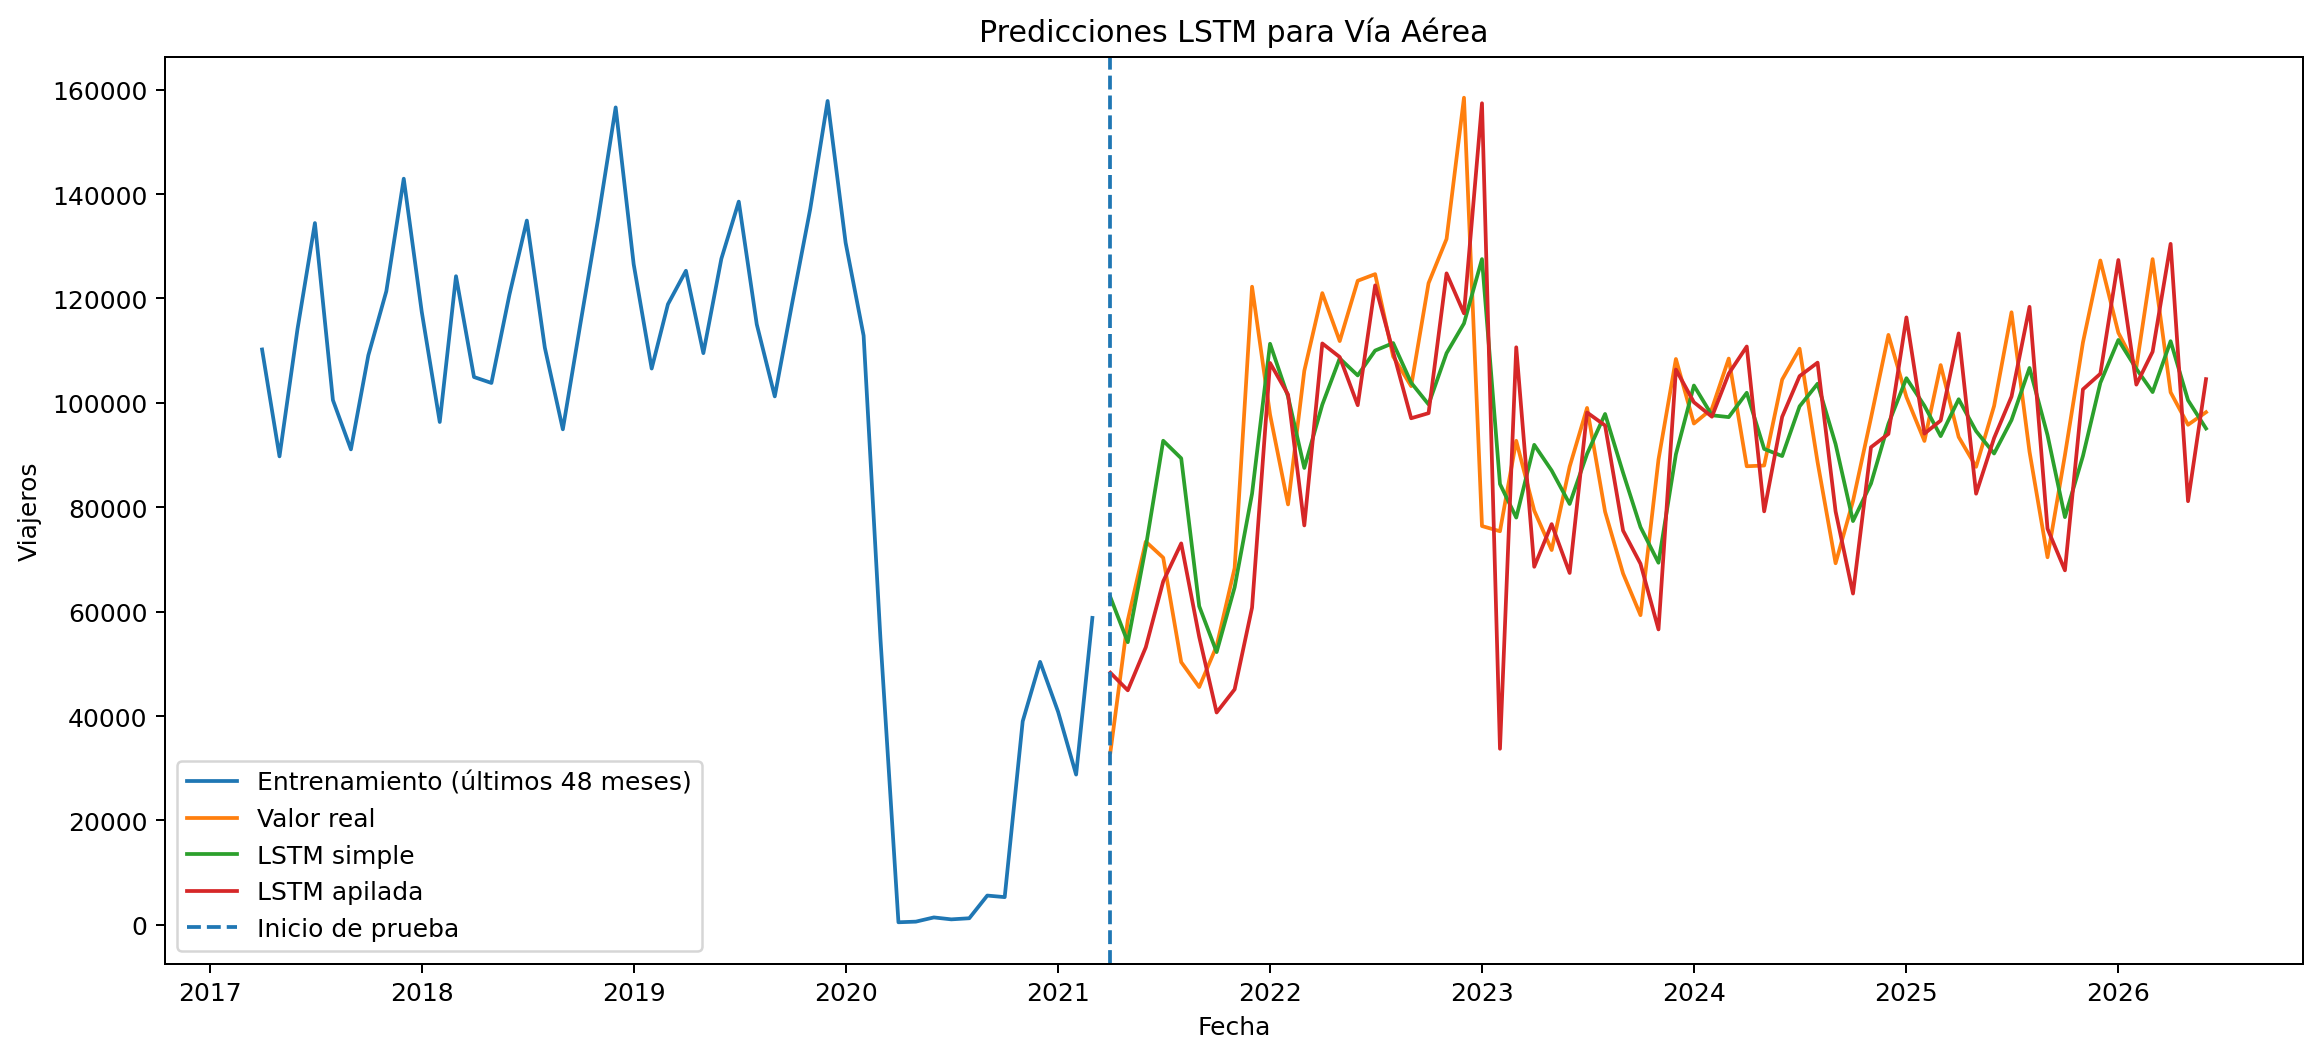

La LSTM simple obtuvo un MAE de 14,491.80 viajeros, un RMSE de 17,959.87 y un sMAPE de 15.97%. La LSTM apilada obtuvo un MAE de 15,524.99, un RMSE de 20,885.71 y un sMAPE de 18.02%.

Ambos modelos siguieron la recuperación posterior a la pandemia y reprodujeron buena parte de las fluctuaciones mensuales. La LSTM simple se mantuvo más cerca de los valores reales en la mayoría de los meses. La arquitectura apilada reaccionó con mayor intensidad a algunos cambios y produjo errores grandes cerca de ciertos picos y caídas.

### Pérdida de entrenamiento — Vía Aérea

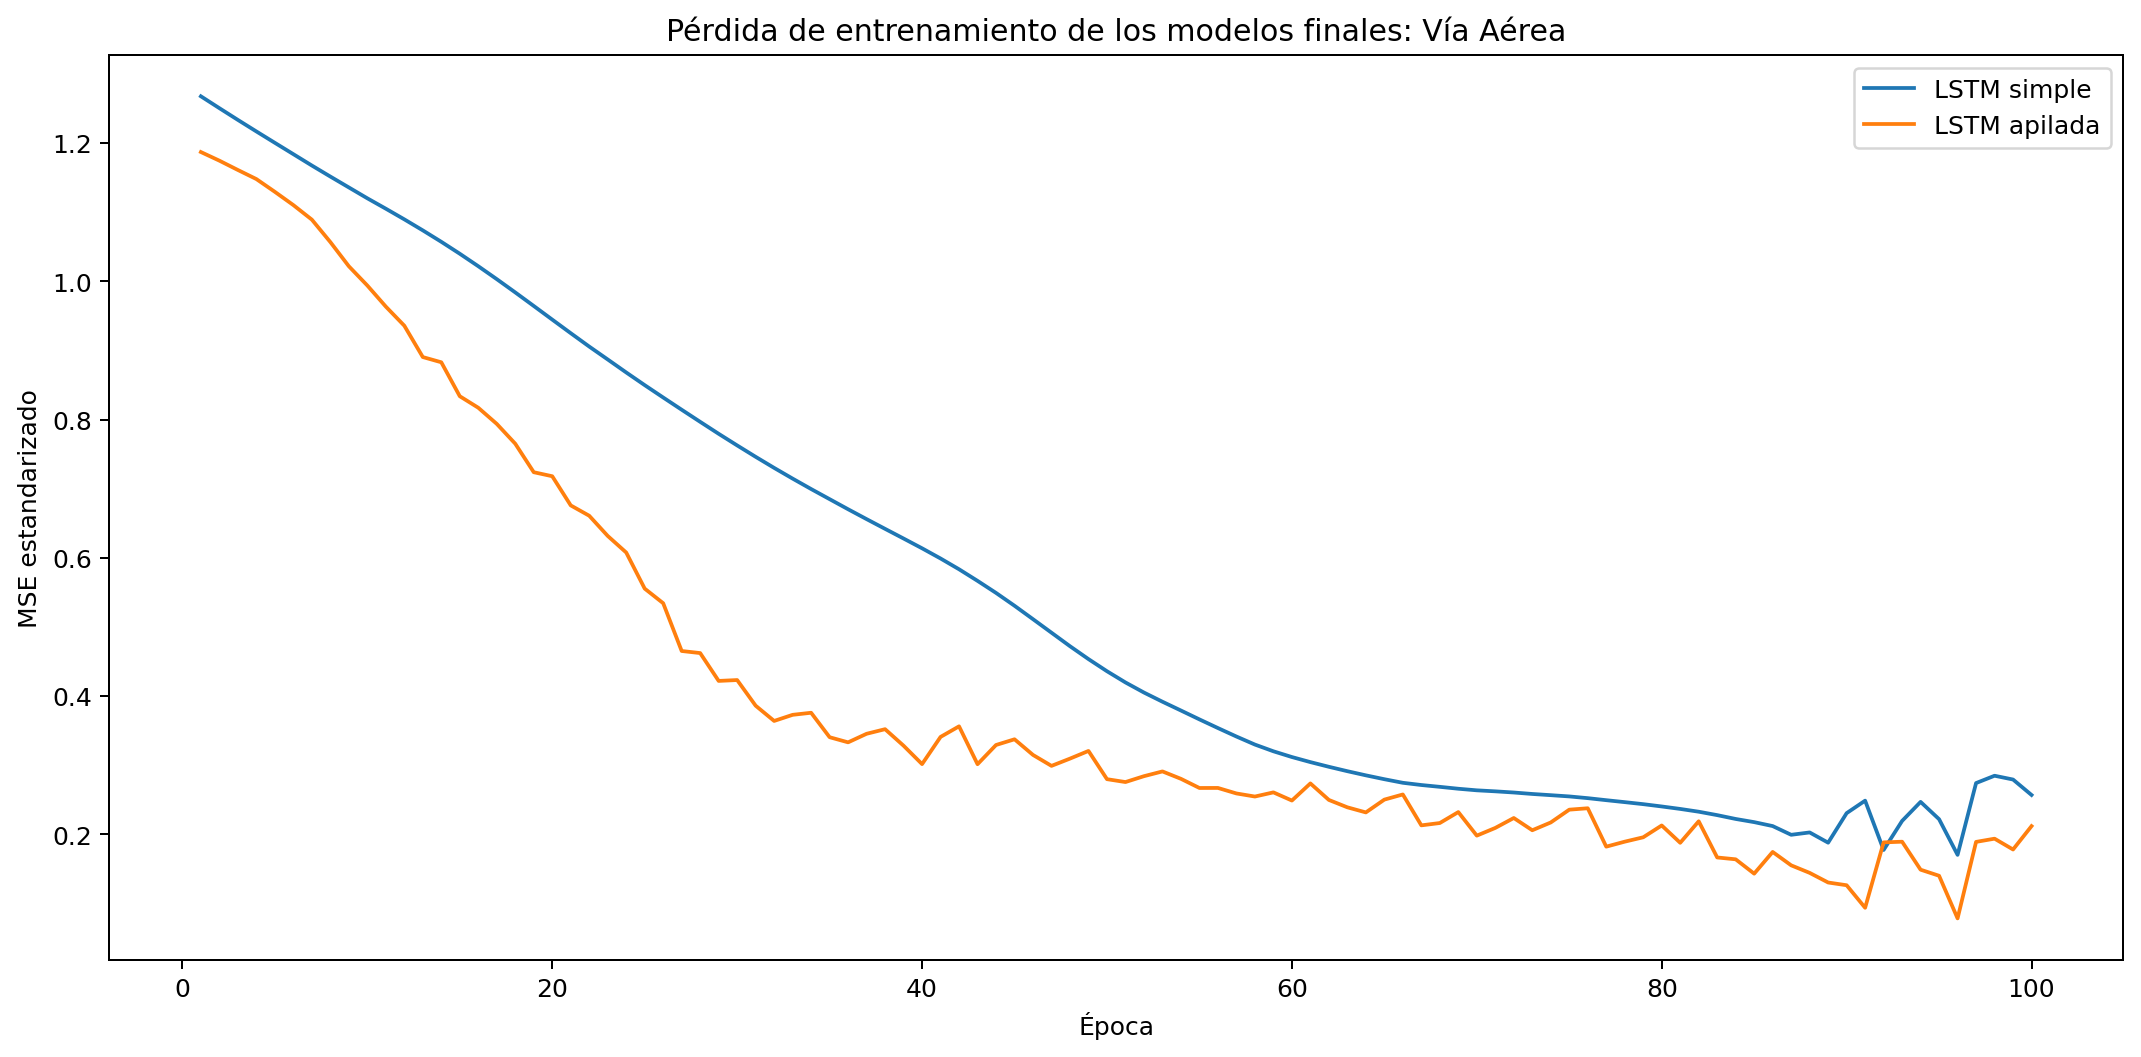

La pérdida disminuyó durante el entrenamiento de ambas arquitecturas. La LSTM simple alcanzó una pérdida final menor y un comportamiento más estable, lo cual es consistente con sus mejores métricas en el conjunto de prueba.

## Serie Vía Terrestre — Tuneo

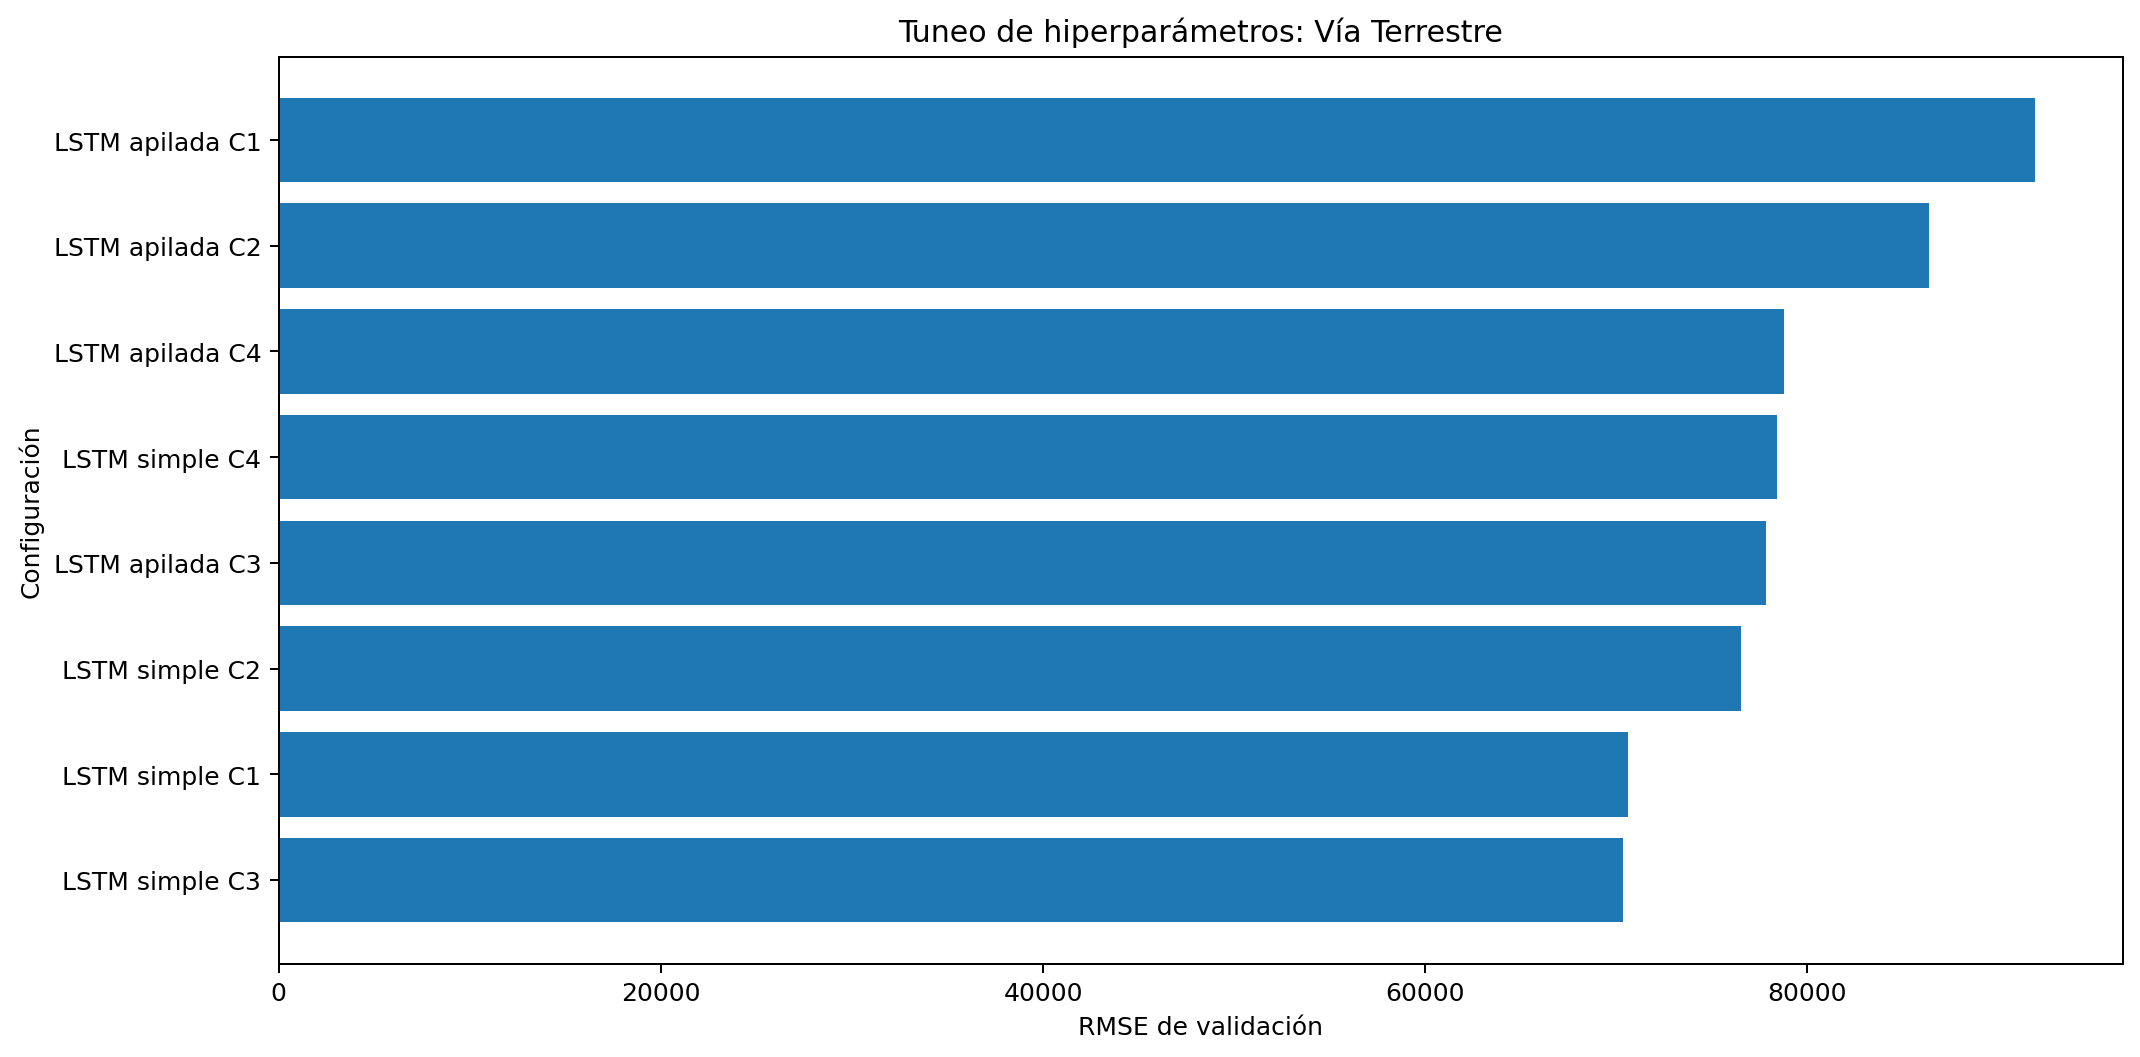

Para Vía Terrestre, la mejor LSTM simple utilizó una ventana de 24 meses y 24 unidades ocultas. La mejor LSTM apilada utilizó 24 meses, 48 unidades y dropout de 0.10. La diferencia entre sus RMSE de validación ya indicaba que la arquitectura simple era la opción más adecuada.

## Serie Vía Terrestre — Predicciones

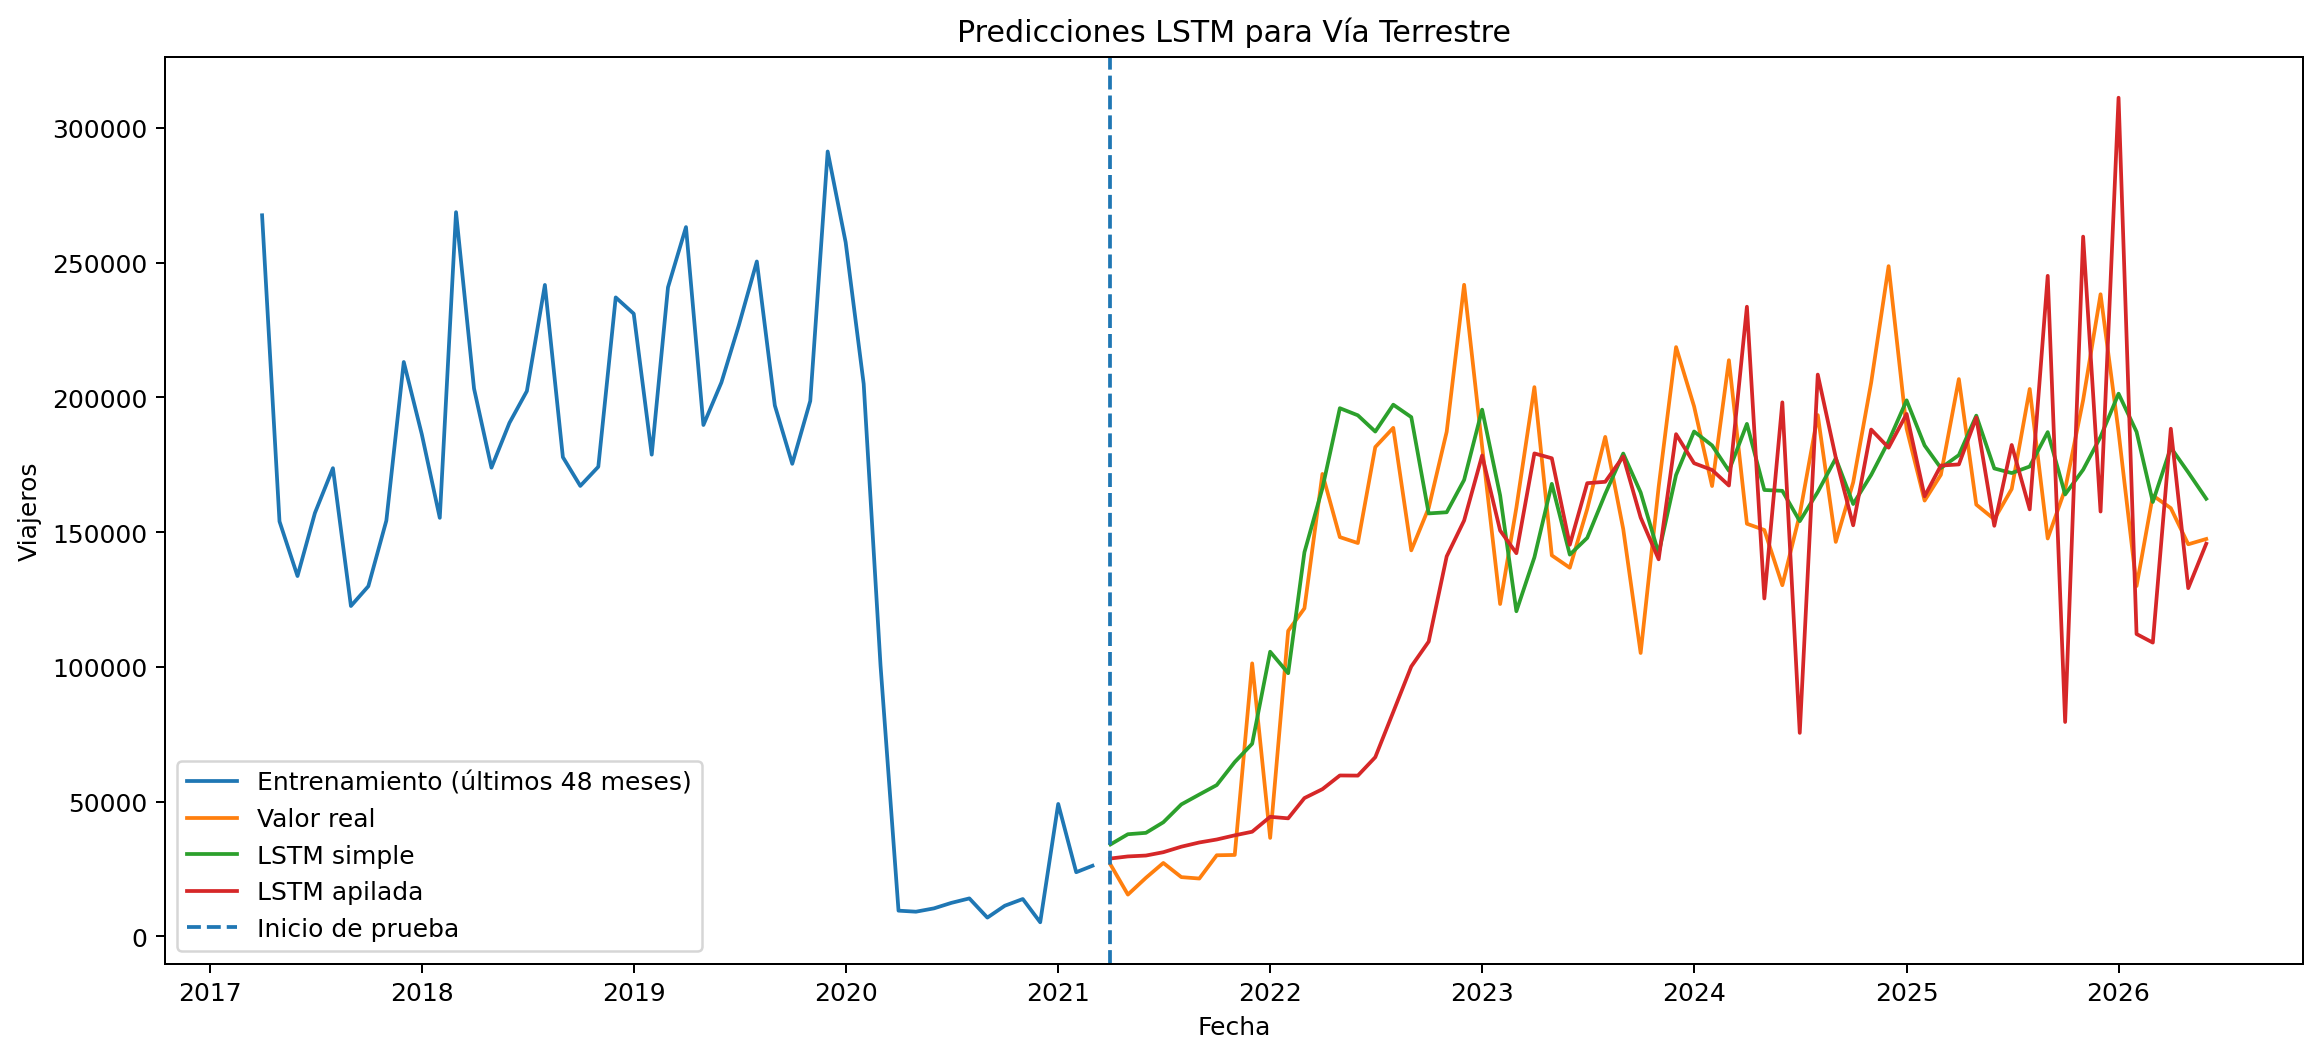

La LSTM simple obtuvo un MAE de 26,841.69 viajeros, un RMSE de 32,280.39 y un sMAPE de 23.22%. La LSTM apilada obtuvo un MAE de 39,317.52, un RMSE de 51,767.09 y un sMAPE de 31.32%.

La LSTM simple se adaptó más rápidamente al crecimiento de la serie durante la recuperación. La arquitectura apilada tardó más en alcanzar el nivel real y posteriormente generó varias sobreestimaciones y subestimaciones fuertes. Esto explica su RMSE considerablemente mayor.

### Pérdida de entrenamiento — Vía Terrestre

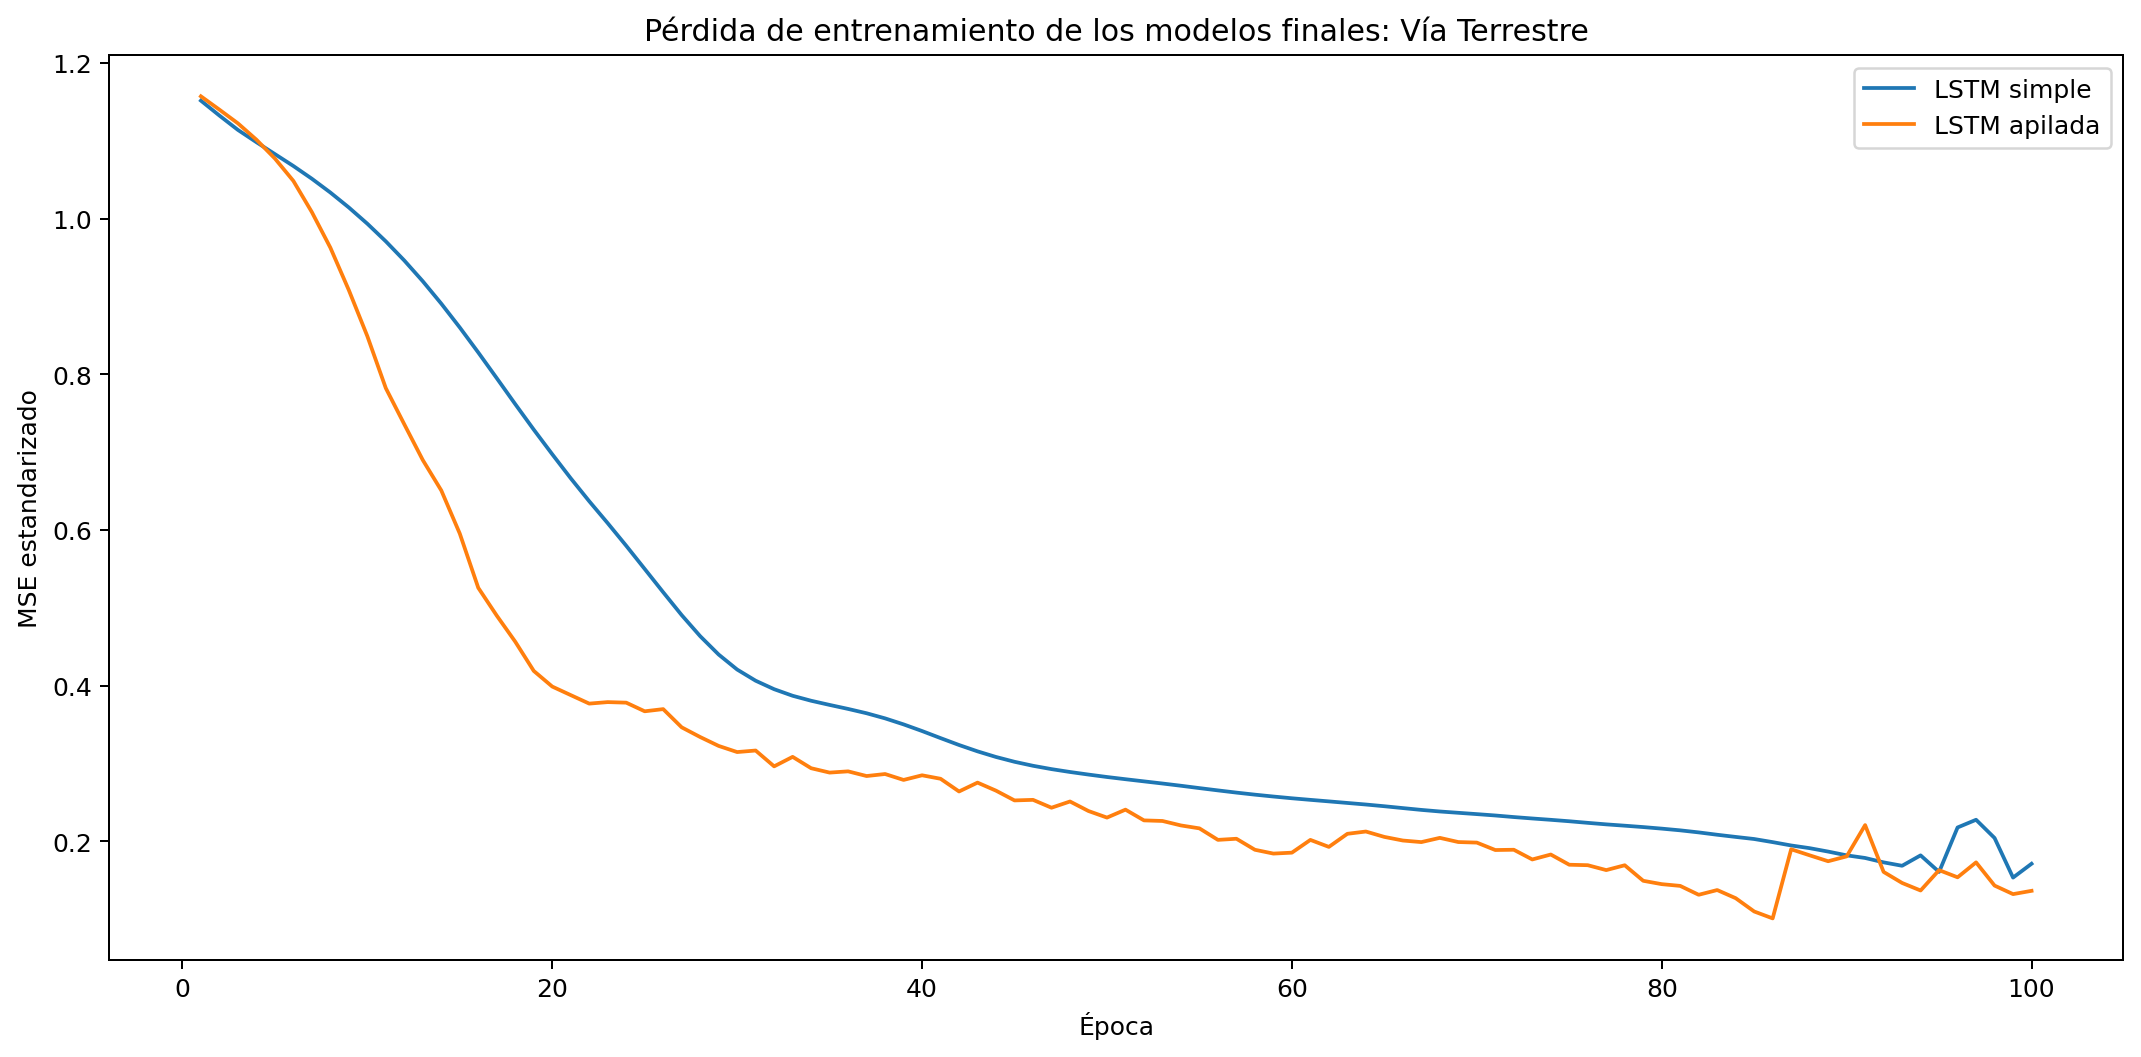

La LSTM simple alcanzó una pérdida de entrenamiento menor que la arquitectura apilada. En esta serie, la red de dos capas no aportó una mejora y mostró mayor sensibilidad a los cambios extremos.

## Conclusiones 

Se construyeron y tunearon dos modelos LSTM diferentes para cada una de las dos series, cumpliendo el requerimiento del avance.

La LSTM simple fue la mejor arquitectura tanto para Vía Aérea como para Vía Terrestre. En todos los casos se seleccionó una ventana de 24 meses, lo que evidencia la utilidad de incluir dos años de historia para representar tendencia y estacionalidad.

El resultado principal es que una arquitectura más profunda no necesariamente generaliza mejor. La cantidad de capas, unidades y dropout debe elegirse mediante validación. Para la entrega final quedará completar la comparación formal con los modelos del Laboratorio 1 y desarrollar el análisis con catch22.

## Repositorio 
https://github.com/Ninaswiftie09/Data_Science/tree/Laboratorio2